In [1]:
import matplotlib.pyplot as plt

# Change the global font settings
plt.rcParams['font.family'] = 'DejaVu Sans Mono'   # Replace 'DejaVu Sans Mono', DejaVu Serif with your preferred font
plt.rcParams['font.size'] = 12          # Set font size
plt.rcParams['axes.titlesize'] = 14     # Title font size
plt.rcParams['axes.labelsize'] = 10     # Axes label font size
plt.rcParams['legend.fontsize'] = 10    # Legend font size
plt.rcParams['xtick.labelsize'] = 10    # X-axis tick font size
plt.rcParams['ytick.labelsize'] = 10    # Y-axis tick font size


In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
from astropy.io import fits 
import pickle 
import matplotlib.colors as colors

In [3]:
science_list = np.genfromtxt('./group15_WASP-12_20191229/science/science.list',dtype=str)
science_frame_name = './group15_WASP-12_20191229/correct/' + science_list[0][:-5] + '_corr.p'
science_corrected =    pickle.load(open(science_frame_name, 'rb'))

In [4]:
def make_annulus_around_star(x_pos, y_pos,  inner_radius, outer_radius, label='', color='y'):
    from matplotlib.patches import Circle

    n, radii = 50, [inner_radius, outer_radius]
    theta = np.linspace(0, 2*np.pi, n, endpoint=True)
    xs = np.outer(radii, np.cos(theta))
    ys = np.outer(radii, np.sin(theta))
    
    # in order to have a closed area, the circles
    # should be traversed in opposite directions
    xs[1,:] = xs[1,::-1]
    ys[1,:] = ys[1,::-1]
    
    ax.fill(np.ravel(xs)+x_pos, np.ravel(ys)+y_pos, edgecolor=None, facecolor=color, alpha=0.75, label=label)



def make_circle_around_star(x_pos, y_pos, radius, thickness=0.5, label='', color='w', alpha=1.):
    from matplotlib.patches import Circle

    n, radii = 50, [radius, radius+thickness]
    theta = np.linspace(0, 2*np.pi, n, endpoint=True)
    xs = np.outer(radii, np.cos(theta))
    ys = np.outer(radii, np.sin(theta))
    
    # in order to have a closed area, the circles
    # should be traversed in opposite directions
    xs[1,:] = xs[1,::-1]
    ys[1,:] = ys[1,::-1]
    
    ax.fill(np.ravel(xs)+x_pos, np.ravel(ys)+y_pos, edgecolor=None, facecolor=color, alpha=alpha, label=label)

vmin:  857.9    vmax: 80367.5


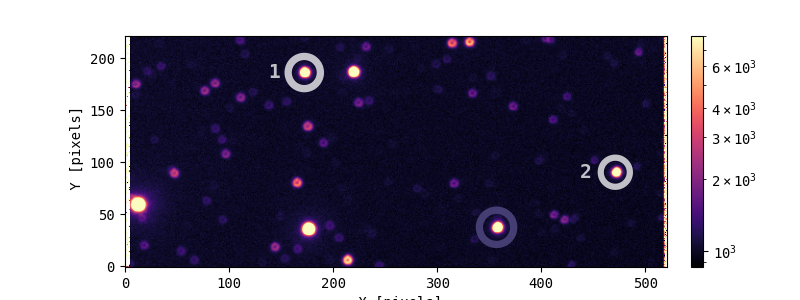

In [5]:
x_target = 357.0
y_target = 37.64

x_reference_01 = 172.21
y_reference_01 = 186.39

x_reference_02 = 471.12
y_reference_02 = 90.58

aperture = 7 
target_inner_radius = 13
target_outer_radius = 20

reference_01_inner_radius = 12
reference_01_outer_radius = 19

reference_02_inner_radius = 11
reference_02_outer_radius = 17

vmin = np.amin(science_corrected[:,100:400])
vmax = np.amax(science_corrected[:,100:400])
print('vmin:  {0:.1f}    vmax: {1:.1f}'.format(vmin, vmax))
vmax = 8000

fig, ax = plt.subplots(1, figsize=(8,3))
im1 = plt.imshow(science_corrected, cmap=plt.colormaps['magma'], norm=colors.LogNorm(vmin=vmin, vmax=vmax), origin='lower')
plt.colorbar(im1,ax=ax, fraction=0.046, pad=0.04)

#make_circle_around_star(x_target, y_target, aperture, label='Aperture')

make_annulus_around_star(x_target, y_target, target_inner_radius, target_outer_radius, label='Target', color='#58508d')
make_annulus_around_star(x_reference_01, y_reference_01, reference_01_inner_radius, reference_01_outer_radius, label='Reference #1', color='w')
make_annulus_around_star(x_reference_02, y_reference_02, reference_02_inner_radius, reference_02_outer_radius, label='Reference #2', color='w')

plt.text(x_reference_01 - 35, y_reference_01, '1', color='w', fontsize=14, ha='left', va='center', alpha=0.75, fontweight='bold')
plt.text(x_reference_02  - 34, y_reference_02, '2', color='w', fontsize=14, ha='left', va='center',alpha=0.75,  fontweight='bold')
# do i need the plot saturated or not? vmax value
plt.xlabel(' X [pixels]')
plt.ylabel(' Y [pixels]')
#ax.legend()
plt.show()

In [6]:
from importlib import reload     # you need to run this line only once 
import aperture_classs            # you need to run this line only once 

In [7]:
from aperture_classs import AperturePhotometry

In [8]:
from time import time
t0 = time()

aperture = 7
target_inner_radius = 13
target_outer_radius = 20

reference_01_inner_radius = 12
reference_01_outer_radius = 19

reference_02_inner_radius = 11
reference_02_outer_radius = 17

target = AperturePhotometry()
target.provide_aperture_parameters(target_inner_radius, target_outer_radius, aperture, x_target, y_target)
target.aperture_photometry()

reference01 = AperturePhotometry()
reference01.provide_aperture_parameters(reference_01_inner_radius, reference_01_outer_radius, aperture, x_reference_01, y_reference_01)
reference01.aperture_photometry()

reference02 = AperturePhotometry()
reference02.provide_aperture_parameters(reference_02_inner_radius, reference_02_outer_radius, aperture, x_reference_02, y_reference_02)
reference02.aperture_photometry()

t1 = time()
print('elapsed_time=', t1-t0)

/root/AstroLab/TASTE_analysis/aperture_classs.py:54: RuntimeWarning: divide by zero encountered in divide
  science_corrected = science_debiased / self.median_normalized_flat
/root/AstroLab/TASTE_analysis/aperture_classs.py:54: RuntimeWarning: invalid value encountered in divide
  science_corrected = science_debiased / self.median_normalized_flat


elapsed_time= 606.1833117008209


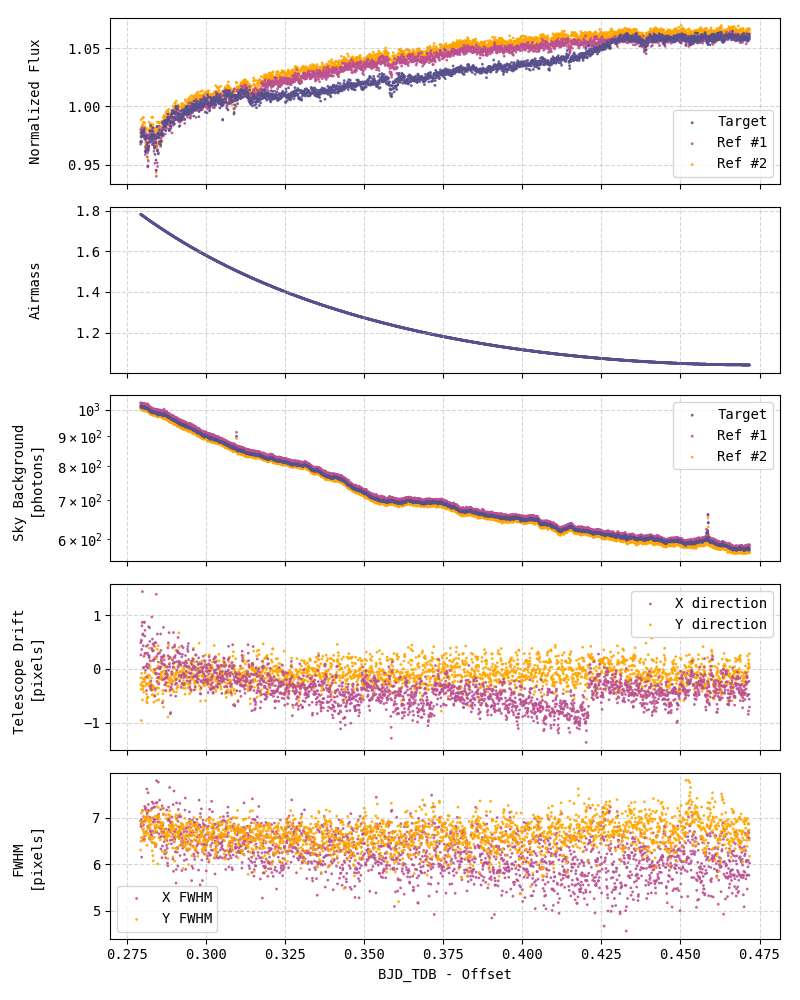

In [9]:
normalization_index = 200
time_offset = 2458847.0

fig, axs = plt.subplots(5, 1, sharex=True, figsize=(8,10))
fig.subplots_adjust(hspace=0.35)
for ax in axs:
    ax.yaxis.set_label_coords(-0.1, 0.5)
    
axs[0].scatter(target.bjd_tdb-time_offset, target.aperture/target.aperture[normalization_index], s=4, zorder=3, c='#58508d', alpha=0.9, edgecolors='none', label='Target')
axs[0].scatter(target.bjd_tdb-time_offset, reference01.aperture/reference01.aperture[normalization_index], s=4, zorder=2, c='#bc5090', alpha=0.9, edgecolors='none', label='Ref #1')
axs[0].scatter(target.bjd_tdb-time_offset, reference02.aperture/reference02.aperture[normalization_index], s=4, zorder=1, c='#ffa600', alpha=0.9, edgecolors='none', label='Ref #2')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].set_ylabel('Normalized Flux', labelpad=10)
axs[0].legend()

axs[1].scatter(target.bjd_tdb-time_offset, target.airmass, s=4, c='#58508d', alpha=0.9, edgecolors='none', label='Airmass')
axs[1].set_ylabel('Airmass', labelpad=15)
axs[1].grid(True, linestyle='--', alpha=0.5)

axs[2].scatter(target.bjd_tdb-time_offset, target.sky_background, s=4, zorder=3, c='#58508d', alpha=0.9, edgecolors='none', label='Target')
axs[2].scatter(target.bjd_tdb-time_offset, reference01.sky_background, s=4, zorder=2, c='#bc5090', alpha=0.9, edgecolors='none', label='Ref #1')
axs[2].scatter(target.bjd_tdb-time_offset, reference02.sky_background, s=4, zorder=1, c='#ffa600', alpha=0.9, edgecolors='none', label='Ref #2')
axs[2].set_ylabel('Sky Background \n[photons]', labelpad=10)
axs[2].set_yscale('log')
axs[2].legend()
axs[2].grid(True, linestyle='--', alpha=0.5)

axs[3].scatter(target.bjd_tdb-time_offset, target.x_position - target.x_position[normalization_index], s=4, zorder=3, c='#bc5090', alpha=0.9, edgecolors='none', label='X direction')
axs[3].scatter(target.bjd_tdb-time_offset, target.y_position - target.y_position[normalization_index], s=4, zorder=2, c='#ffa600', alpha=0.9, edgecolors='none', label='Y direction')
axs[3].set_ylabel('Telescope Drift \n[pixels]', labelpad=10)
axs[3].legend()
axs[3].grid(True, linestyle='--', alpha=0.5)

axs[4].scatter(target.bjd_tdb - time_offset, target.x_fwhm, s=4, c='#bc5090', alpha=0.9, edgecolors='none', label='X FWHM', zorder=3)
axs[4].scatter(target.bjd_tdb - time_offset, target.y_fwhm, s=4, c='#ffa600', alpha=0.9, edgecolors='none', label='Y FWHM', zorder=3)
axs[4].set_ylabel('FWHM \n[pixels]', labelpad=10)
axs[4].set_xlabel('BJD_TDB - Offset') 
axs[4].legend()
axs[4].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.gca().set_facecolor('none')
plt.show()

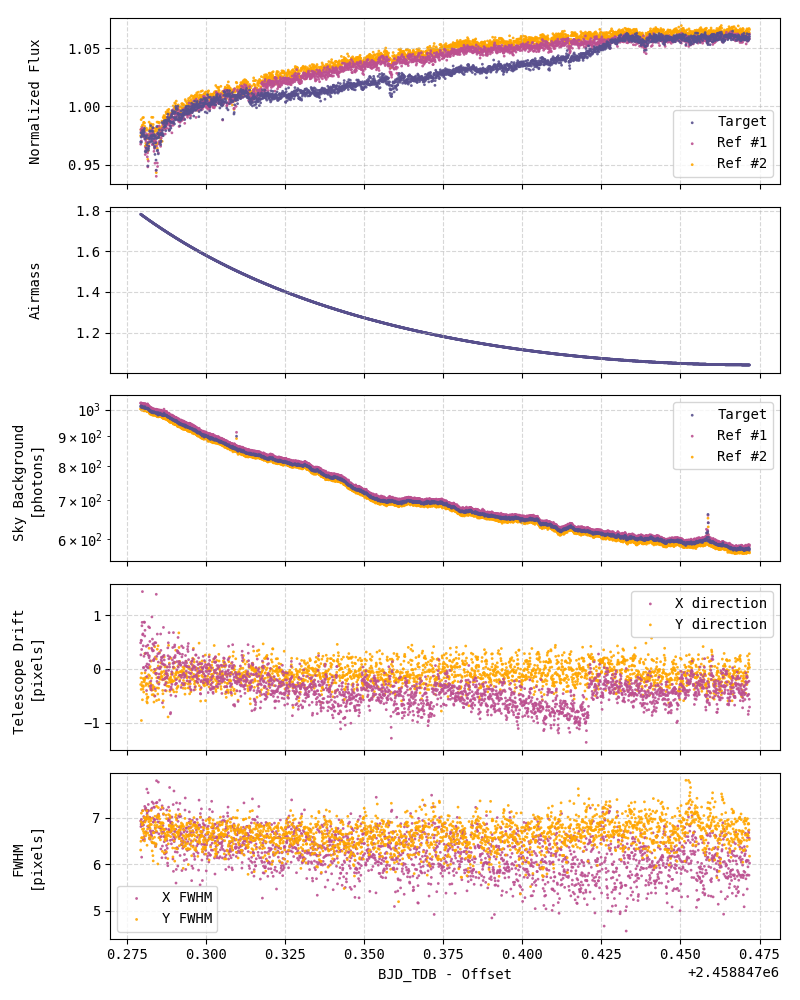

In [15]:
normalization_index = 200
time_offset = 2458847.0

fig, axss = plt.subplots(5, 1, sharex=True, figsize=(8,10))
fig.subplots_adjust(hspace=0.35)
for ax in axss:
    ax.yaxis.set_label_coords(-0.1, 0.5)
    
axss[0].scatter(target.bjd_tdb, target.aperture/target.aperture[normalization_index], s=4, zorder=3, c='#58508d', alpha=0.9, edgecolors='none', label='Target')
axss[0].scatter(target.bjd_tdb, reference01.aperture/reference01.aperture[normalization_index], s=4, zorder=2, c='#bc5090', alpha=0.9, edgecolors='none', label='Ref #1')
axss[0].scatter(target.bjd_tdb, reference02.aperture/reference02.aperture[normalization_index], s=4, zorder=1, c='#ffa600', alpha=0.9, edgecolors='none', label='Ref #2')
axss[0].grid(True, linestyle='--', alpha=0.5)
axss[0].set_ylabel('Normalized Flux', labelpad=10)
axss[0].legend()

axss[1].scatter(target.bjd_tdb, target.airmass, s=4, c='#58508d', alpha=0.9, edgecolors='none', label='Airmass')
axss[1].set_ylabel('Airmass', labelpad=15)
axss[1].grid(True, linestyle='--', alpha=0.5)

axss[2].scatter(target.bjd_tdb, target.sky_background, s=4, zorder=3, c='#58508d', alpha=0.9, edgecolors='none', label='Target')
axss[2].scatter(target.bjd_tdb, reference01.sky_background, s=4, zorder=2, c='#bc5090', alpha=0.9, edgecolors='none', label='Ref #1')
axss[2].scatter(target.bjd_tdb, reference02.sky_background, s=4, zorder=1, c='#ffa600', alpha=0.9, edgecolors='none', label='Ref #2')
axss[2].set_ylabel('Sky Background \n[photons]', labelpad=10)
axss[2].set_yscale('log')
axss[2].legend()
axss[2].grid(True, linestyle='--', alpha=0.5)

axss[3].scatter(target.bjd_tdb, target.x_position - target.x_position[normalization_index], s=4, zorder=3, c='#bc5090', alpha=0.9, edgecolors='none', label='X direction')
axss[3].scatter(target.bjd_tdb, target.y_position - target.y_position[normalization_index], s=4, zorder=2, c='#ffa600', alpha=0.9, edgecolors='none', label='Y direction')
axss[3].set_ylabel('Telescope Drift \n[pixels]', labelpad=10)
axss[3].legend()
axss[3].grid(True, linestyle='--', alpha=0.5)

axss[4].scatter(target.bjd_tdb, target.x_fwhm, s=4, c='#bc5090', alpha=0.9, edgecolors='none', label='X FWHM', zorder=3)
axss[4].scatter(target.bjd_tdb, target.y_fwhm, s=4, c='#ffa600', alpha=0.9, edgecolors='none', label='Y FWHM', zorder=3)
axss[4].set_ylabel('FWHM \n[pixels]', labelpad=10)
axss[4].set_xlabel('BJD_TDB - Offset') 
axss[4].legend()
axss[4].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.gca().set_facecolor('none')
plt.show()

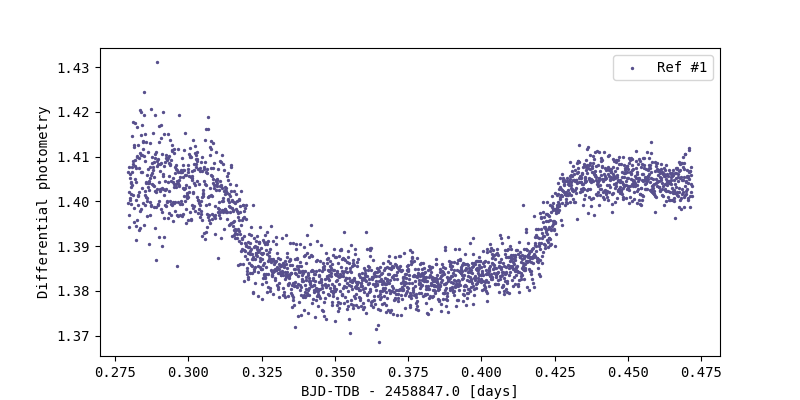

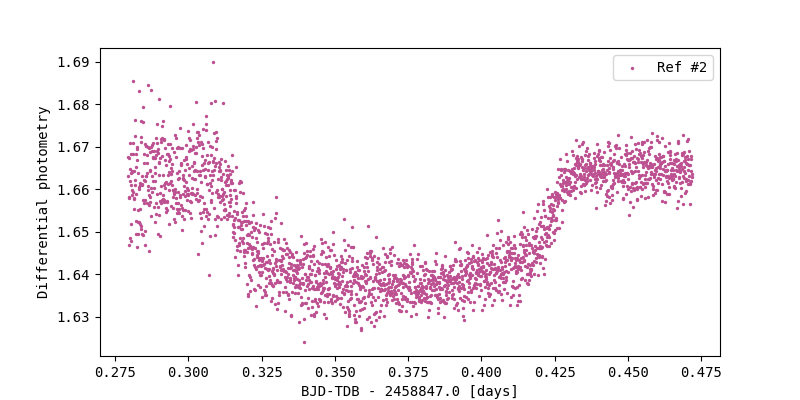

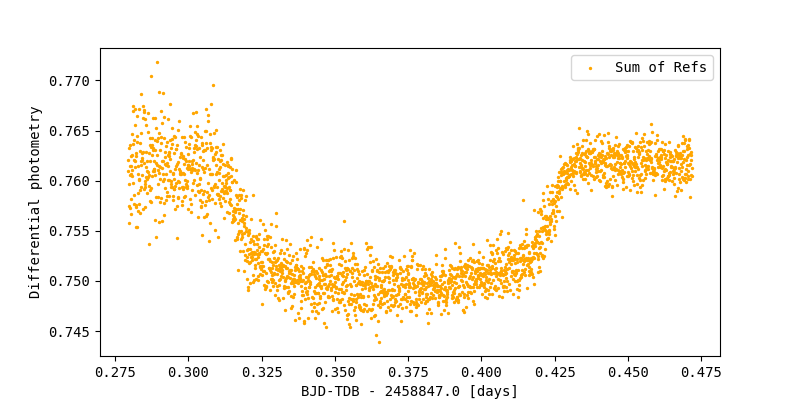

In [10]:
plt.figure(figsize=(8,4))
plt.scatter(target.bjd_tdb-time_offset, target.aperture/reference01.aperture, s=2, c='#58508d', label='Ref #1')
plt.xlabel('BJD-TDB - {0:.1f} [days]'.format(time_offset))
plt.ylabel('Differential photometry')
#plt.ylim(2.200, 2.300)
plt.legend()
plt.show()


plt.figure(figsize=(8,4))
plt.scatter(target.bjd_tdb-time_offset, target.aperture/reference02.aperture, s=2, c='#bc5090', label='Ref #2')
plt.xlabel('BJD-TDB - {0:.1f} [days]'.format(time_offset))
plt.ylabel('Differential photometry')
#plt.ylim(0.268, 0.278)
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.scatter(target.bjd_tdb-time_offset, target.aperture/(reference01.aperture+reference02.aperture), s=2, c='#ffa600', label='Sum of Refs')
plt.xlabel('BJD-TDB - {0:.1f} [days]'.format(time_offset))
plt.ylabel('Differential photometry')
#plt.ylim(0.240, 0.250)
plt.legend()
plt.show()

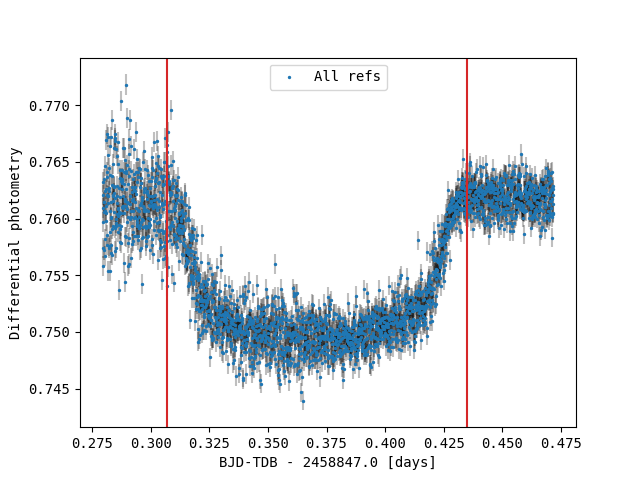

In [11]:
diff_ref01 = target.aperture / reference01.aperture
diff_ref02 = target.aperture / reference02.aperture

    #  Errors in ratio = ratio * sqrt( (err_target/target)^2 + (err_ref/ref)^2 )
diff_ref01_err = diff_ref01 * np.sqrt(
        (target.aperture_errors/target.aperture)**2 +
        (reference01.aperture_errors/reference01.aperture)**2
)
diff_ref02_err = diff_ref02 * np.sqrt(
        (target.aperture_errors/target.aperture)**2 +
        (reference02.aperture_errors/reference02.aperture)**2
)

    #  Sum of references:
sum_refs = reference01.aperture + reference02.aperture
sum_refs_err = np.sqrt(reference01.aperture_errors**2 + reference02.aperture_errors**2)
diff_allref = target.aperture / sum_refs
diff_allref_err = diff_allref * np.sqrt(
        (target.aperture_errors/target.aperture)**2 +
        (sum_refs_err/sum_refs)**2
)

plt.figure()
plt.scatter(target.bjd_tdb-time_offset, diff_allref, s=2, label='All refs')
plt.errorbar(target.bjd_tdb-time_offset, diff_allref, yerr=diff_allref_err, fmt=' ', c='k', alpha=0.25, zorder=-1) 
plt.legend()
plt.axvline(2458847.307-time_offset, c='C3')
plt.axvline(2458847.435-time_offset, c='C3')
plt.xlabel('BJD-TDB - {0:.1f} [days]'.format(time_offset))
plt.ylabel('Differential photometry')
#plt.ylim(0.240, 0.250)
plt.show()

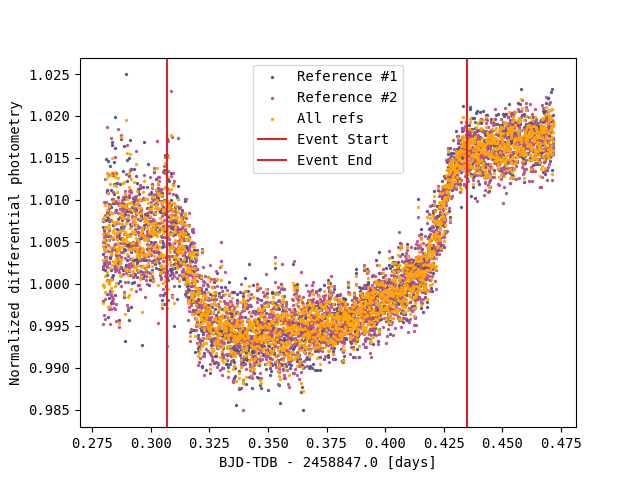

Standard deviation reference #1: 0.0067525
Standard deviation reference #2: 0.0065143
Standard deviation all references: 0.0064397


In [12]:
bjd_tdb = target.bjd_tdb
bjd_median = np.median(target.bjd_tdb)

# Import Polynomial
from numpy.polynomial import Polynomial

# Define out-of-transit selection
out_transit_selection = ((target.bjd_tdb < 2458847.307) | (target.bjd_tdb > 2458847.307)) & (target.bjd_tdb < 2458847.435)

# Polynomial fits for out-of-transit data
poly_ref01_deg01_pfit = Polynomial.fit(
    bjd_tdb[out_transit_selection] - bjd_median, 
    diff_ref01[out_transit_selection], 
    deg=1
)

poly_ref02_deg01_pfit = Polynomial.fit(
    bjd_tdb[out_transit_selection] - bjd_median, 
    diff_ref02[out_transit_selection], 
    deg=1
)

poly_allref_deg01_pfit = Polynomial.fit(
    bjd_tdb[out_transit_selection] - bjd_median, 
    diff_allref[out_transit_selection], 
    deg=1
)

# Normalize differential photometry
differential_ref01_normalized = diff_ref01 / poly_ref01_deg01_pfit(bjd_tdb - bjd_median)
differential_ref02_normalized = diff_ref02 / poly_ref02_deg01_pfit(bjd_tdb - bjd_median)
differential_allref_normalized = diff_allref / poly_allref_deg01_pfit(bjd_tdb - bjd_median)

# Compute normalized errors
differential_ref01_normalized_error = diff_ref01_err / poly_ref01_deg01_pfit(bjd_tdb - bjd_median)
differential_ref02_normalized_error = diff_ref02_err / poly_ref02_deg01_pfit(bjd_tdb - bjd_median)
differential_allref_normalized_error = diff_allref_err / poly_allref_deg01_pfit(bjd_tdb - bjd_median)

# Plot normalized differential photometry
plt.figure()
plt.scatter(bjd_tdb - time_offset, differential_ref01_normalized, s=2, label='Reference #1', c='#58508d', alpha=0.9)
plt.scatter(bjd_tdb - time_offset, differential_ref02_normalized, s=2, label='Reference #2', c='#bc5090', alpha=0.9)
plt.scatter(bjd_tdb - time_offset, differential_allref_normalized, s=2, label='All refs', c='#ffa600', alpha=0.9)
plt.axvline(2458847.307 - time_offset, c='C3', label='Event Start')
plt.axvline(2458847.435 - time_offset, c='C3', label='Event End')
#plt.ylim(0.975, 1.025)
plt.xlabel('BJD-TDB - {0:.1f} [days]'.format(time_offset))
plt.ylabel('Normalized differential photometry')
plt.legend()
plt.show()

# Print standard deviations
print('Standard deviation reference #1: {0:.7f}'.format(
    np.std(differential_ref01_normalized[out_transit_selection])))
print('Standard deviation reference #2: {0:.7f}'.format(
    np.std(differential_ref02_normalized[out_transit_selection])))
print('Standard deviation all references: {0:.7f}'.format(
    np.std(differential_allref_normalized[out_transit_selection])))


In [97]:
pickle.dump(bjd_tdb, open('taste_bjdtdb.p','wb'))
pickle.dump(differential_ref01_normalized, open('differential_ref01_normalized.p','wb'))
pickle.dump(differential_ref01_normalized_error,open('differential_ref01_normalized_error.p','wb'))
pickle.dump(differential_allref_normalized, open('differential_allref_normalized.p','wb'))
pickle.dump(differential_allref_normalized_error, open('differential_allref_normalized_error.p','wb'))
pickle.dump(diff_ref01, open('differential_ref01.p','wb'))
pickle.dump(diff_ref01_err, open('differential_ref01_error.p','wb'))
pickle.dump(diff_allref, open('differential_allref.p', 'wb'))
pickle.dump(diff_allref_err, open('differential_allref_error.p','wb'))